<a href="https://colab.research.google.com/github/TowsifTazwar/data-science-research/blob/main/8_Introduction_to_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [5]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Datasets/ObesityDataSet_raw_and_data_sinthetic.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [7]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2111, 17)

Columns:
Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

Missing Values:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Data Types:
Gender                             object
Age                                 int64
Height   

In [8]:
# Create copy
data = df.copy()

# Encode all categorical columns
encoder = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = encoder.fit_transform(data[col])

data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21,1.62,64.0,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1
1,0,21,1.52,56.0,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1
2,1,23,1.80,77.0,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1
3,1,27,1.80,87.0,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5
4,1,22,1.78,89.8,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6


In [9]:
X = data.drop("NObeyesdad", axis=1)
y = data["NObeyesdad"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples: (1688, 16)
Testing Samples : (423, 16)


In [11]:
## Test Different Tree Depths

depths = [2, 3, 4, 5, 6, 7]

accuracy_list = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    acc = accuracy_score(y_test, prediction)

    accuracy_list.append(acc)

    print(f"Max Depth = {depth} ---> Accuracy = {acc:.4f}")

Max Depth = 2 ---> Accuracy = 0.5390
Max Depth = 3 ---> Accuracy = 0.6643
Max Depth = 4 ---> Accuracy = 0.7778
Max Depth = 5 ---> Accuracy = 0.8203
Max Depth = 6 ---> Accuracy = 0.9007
Max Depth = 7 ---> Accuracy = 0.8960


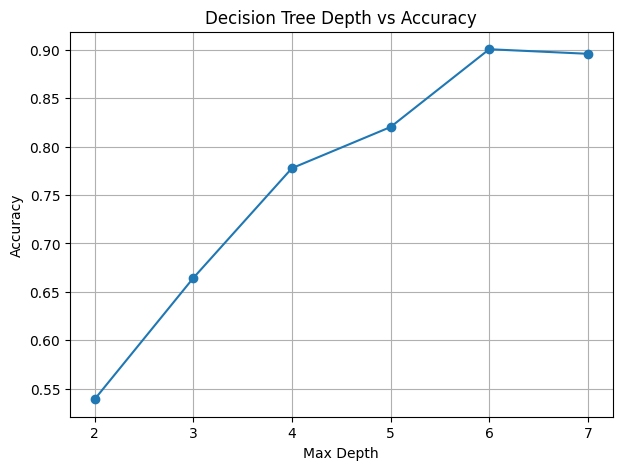

In [12]:
plt.figure(figsize=(7,5))

## Plot Accuracy vs Depth

plt.plot(depths, accuracy_list, marker='o')

plt.title("Decision Tree Depth vs Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

In [13]:
## Best Depth

best_depth = depths[np.argmax(accuracy_list)]

print("Best Depth:", best_depth)
print("Best Accuracy:", max(accuracy_list))

Best Depth: 6
Best Accuracy: 0.900709219858156


In [14]:
## Train Best Decision Tree

best_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [15]:
## Calculate Metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.900709219858156
Precision: 0.9091280640196009
Recall   : 0.900709219858156
F1 Score : 0.902902428378924


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.83      0.89        54
           1       0.73      0.76      0.75        58
           2       0.97      0.94      0.96        70
           3       0.97      0.97      0.97        60
           4       1.00      0.98      0.99        65
           5       0.73      0.90      0.81        58
           6       0.98      0.90      0.94        58

    accuracy                           0.90       423
   macro avg       0.91      0.90      0.90       423
weighted avg       0.91      0.90      0.90       423



In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,Weight,0.468745
2,Height,0.222840
0,Gender,0.184462
1,Age,0.040012
14,CALC,0.026824
5,FAVC,0.024197
8,CAEC,0.015218
6,FCVC,0.012389
13,TUE,0.003695
7,NCP,0.001616


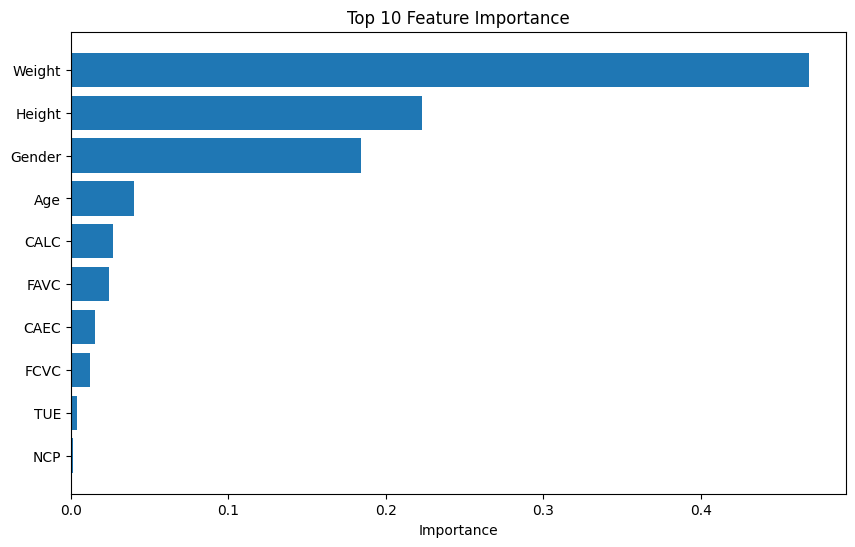

In [18]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")

plt.show()

In [19]:
## Print Top 10 Features

print(top10)

   Feature  Importance
3   Weight    0.468745
2   Height    0.222840
0   Gender    0.184462
1      Age    0.040012
14    CALC    0.026824
5     FAVC    0.024197
8     CAEC    0.015218
6     FCVC    0.012389
13     TUE    0.003695
7      NCP    0.001616


<Figure size 800x800 with 0 Axes>

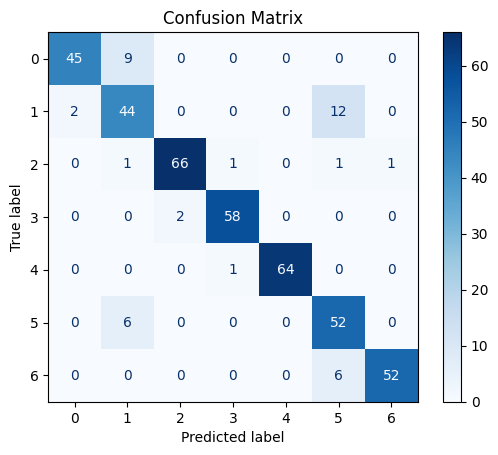

In [20]:
## Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

plt.figure(figsize=(8,8))

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [21]:
## Final Answers

print("Question 1")
print("-----------")
print(f"Best Max Depth = {best_depth}")
print(f"Accuracy = {accuracy:.4f}")

print("\nQuestion 2")
print("-----------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nQuestion 3")
print("-----------")
print("Top 10 Important Features:")
print(top10)

print("\nQuestion 4")
print("-----------")
print("The confusion matrix shows which obesity classes are predicted correctly and which are confused with other classes. Misclassification generally occurs between neighboring obesity levels because they share similar physical and lifestyle characteristics.")

Question 1
-----------
Best Max Depth = 6
Accuracy = 0.9007

Question 2
-----------
Accuracy  : 0.9007
Precision : 0.9091
Recall    : 0.9007
F1 Score  : 0.9029

Question 3
-----------
Top 10 Important Features:
   Feature  Importance
3   Weight    0.468745
2   Height    0.222840
0   Gender    0.184462
1      Age    0.040012
14    CALC    0.026824
5     FAVC    0.024197
8     CAEC    0.015218
6     FCVC    0.012389
13     TUE    0.003695
7      NCP    0.001616

Question 4
-----------
The confusion matrix shows which obesity classes are predicted correctly and which are confused with other classes. Misclassification generally occurs between neighboring obesity levels because they share similar physical and lifestyle characteristics.
